In [ ]:
# Homework Repo Setup

# 1. ENTER your GitHub username
github_username ="Cipher212"

# 2. Name of the repo
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Instructor's repo for syncing updates
instructor_url = "https://github.com/abrown9008/STAT-7220-Applied-Experimental-Design.git"

# 4. Build your fork URL
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Ensure we start from /content (standard for Google Colab) ---
initial_cwd = os.getcwd()
if initial_cwd != "/content":
    try:
        os.chdir("/content")
        print(f"🌍 Changed to /content from {initial_cwd}")
    except:
        print(f"⚠️ Could not change to /content. Currently at: {os.getcwd()}")
else:
    print(f"🌍 Already in /content.")


# --- Handle repo cloning ---
if os.path.exists(repo_name) and os.path.isdir(repo_name):
    os.chdir(repo_name)
    print(f"✅ Repo '{repo_name}' already exists.")
else:
    print(f"📥 Cloning fork from {repo_url}...")
    os.system(f"git clone {repo_url}")
    os.chdir(repo_name)

# --- SYNC: Pull the latest Final-Exam folder from Instructor ---
print("🔄 Syncing Final-Exam folder from instructor...")
# Add the instructor as 'upstream' if it doesn't exist
os.system(f"git remote add upstream {instructor_url} 2>/dev/null")
# Fetch the latest data
os.system("git fetch upstream")
# Specifically pull ONLY the Final-Exam folder
os.system("git checkout upstream/main -- Assignments/Final-Exam")

# --- Set Today's Directory ---
today_dir = "Assignments/Final-Exam"
if os.path.exists(today_dir) and os.path.isdir(today_dir):
    os.chdir(today_dir)
    print(f"📂 Active Directory: {os.getcwd()}")
else:
    print(f"❌ ERROR: '{today_dir}' not found.")

# --- Final Check ---
remote_url = os.popen("git config --get remote.origin.url").read().strip()
print(f"🔗 Connected to fork: {remote_url}")

🌍 Already in /content.
📥 Cloning fork from https://github.com/Cipher212/STAT-7220-Applied-Experimental-Design.git...
🔄 Syncing Final-Exam folder from instructor...
📂 Active Directory: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam
🔗 Connected to fork: https://github.com/Cipher212/STAT-7220-Applied-Experimental-Design.git


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:


1. Briefly state the objective of the experiment.
**Ans:** : To determine the effect of protein type, salsa spiciness and presence of potatoes on customer satisfaction

2. State the outcome variable and how it was measured:
**Ans:** Satisfaction. Continuous numerical variable on scale of 0-10

3. State the independent variables. What lurking variables may be present?
**Ans:** Protein, Salsa and Potatoes. Lurking variables are customer's mood and hunger level on entry, time of day, individual taste preferences, freshness of ingredients, performance of kitchen staff of making each burrito identically.

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?
**Ans:** 2^k design would be for 2 levels whereas this experiment has Protein variable with 3 possible choices. It also allows for 2 way and 3 way interactions in our tables.


5. State all sets of statistical hypotheses.
**Ans:**

**Main Effects**

Null Hypothesis: The means of all levels for the factor are equal.
Alternative Hypothesis: At least one level mean differs.

**2- Way Interactions**

Null Hypothesis: There is no interaction effect between the two factors.
Alternative Hypothesis: There is an interaction effect between the factors.

**3- Way Interaction**

Null Hypothesis: There is no three-way interaction effect.
Alternative Hypothesis: There is a three-way interaction effect.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

**Ans:** EDA shows clear main effects. The customers prefer mild salsa, added potatoes, and chorizo or bacon over susage. potential interaction effects, as the impact of salsa heat appears to vary depending on the protein type. Dataset is balanced with 10 replicates per group.

Currently,  EDA currently supports the alternative hypotheses for all three main effects. Inconclusive for 2 way and 3 way interaction.


Summary Statistics by Group:
                        mean   std  count
Protein Salsa Potatoes                   
Bacon   Hot   No        6.23  0.93     10
              Yes       6.67  0.79     10
        Mild  No        7.33  0.78     10
              Yes       7.17  0.90     10
Chorizo Hot   No        6.11  0.86     10
              Yes       6.83  1.22     10
        Mild  No        7.62  1.06     10
              Yes       7.47  0.99     10
Sausage Hot   No        4.86  0.65     10
              Yes       5.72  1.09     10
        Mild  No        5.86  0.67     10
              Yes       6.65  0.97     10

Overall Means by Factor:
Protein
Bacon      6.85
Chorizo    7.01
Sausage    5.77
Name: Satisfaction, dtype: float64
Salsa
Hot     6.07
Mild    7.02
Name: Satisfaction, dtype: float64
Potatoes
No     6.34
Yes    6.75
Name: Satisfaction, dtype: float64


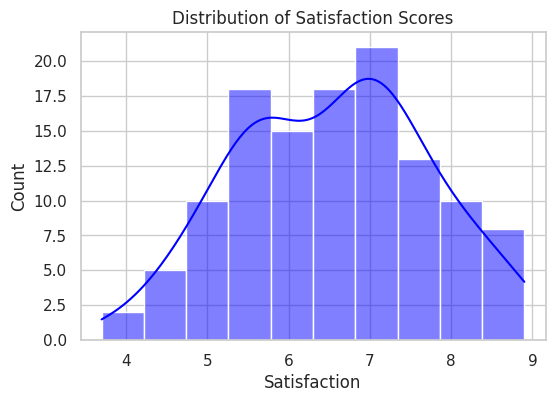

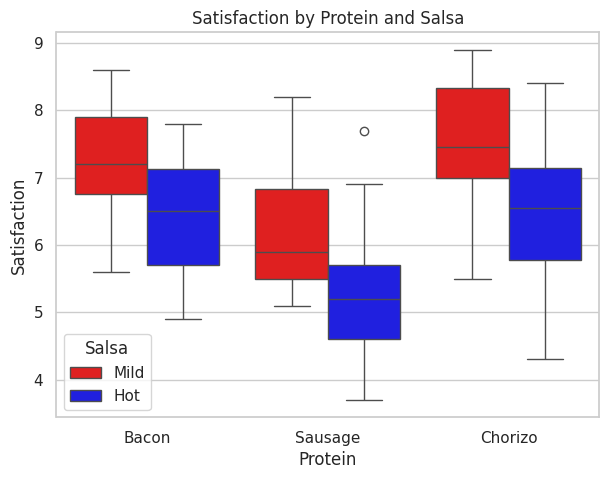

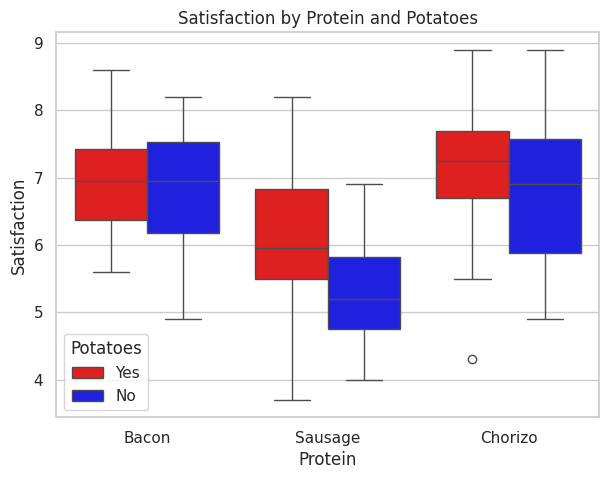

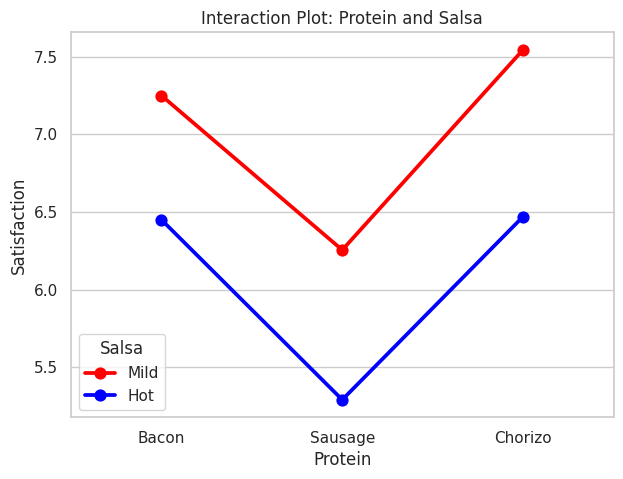

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import scipy.stats as stats


# Load the Excel dataset directly
df = pd.read_excel('Busters Burritos.xlsx')

# 1. Summary Statistics
print("Summary Statistics by Group:")
summary = df.groupby(['Protein', 'Salsa', 'Potatoes'])['Satisfaction'].agg(['mean', 'std', 'count']).round(2)
print(summary)

print("\nOverall Means by Factor:")
print(df.groupby('Protein')['Satisfaction'].mean().round(2))
print(df.groupby('Salsa')['Satisfaction'].mean().round(2))
print(df.groupby('Potatoes')['Satisfaction'].mean().round(2))

# 2. Visualizations
sns.set_theme(style="whitegrid")

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(df['Satisfaction'], bins=10, kde=True, color="blue")
plt.title('Distribution of Satisfaction Scores')
plt.show()

# Boxplot for Protein and Salsa
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Protein', y='Satisfaction', hue='Salsa', palette=["red", "blue"])
plt.title('Satisfaction by Protein and Salsa')
plt.show()

# Boxplot for Protein and Potatoes
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Protein', y='Satisfaction', hue='Potatoes', palette=["red", "blue"])
plt.title('Satisfaction by Protein and Potatoes')
plt.show()

# Line Graph (Interaction Plot)
plt.figure(figsize=(7,5))
sns.pointplot(data=df, x='Protein', y='Satisfaction', hue='Salsa', errorbar=None, palette=["red", "blue"])
plt.title('Interaction Plot: Protein and Salsa')
plt.show()

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

In [ ]:
## Question 7 Code ##


model = ols('Satisfaction ~ C(Protein) * C(Salsa) * C(Potatoes)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(" RESULTS")
print(anova_table)


residuals = model.resid

# shapiro wilke test
shapiro_test = stats.shapiro(residuals)
print(f"\n--- NORMALITY TEST ---")
print(f"Shapiro-Wilk Test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# qqplot

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles (Residuals)")
plt.show()

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [ ]:
## Question 9 Code ##

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [ ]:
## Question 10 Code ##

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [ ]:
## Question 11 Code ##

12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

2. Specify the outcome variable and how it is measured.

3. Specify the independent variables. What lurking variables may be present?

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [ ]:
## Question 6 Code ##

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

In [ ]:
## Question 8 Code ##

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

In [ ]:
## Question 9 Code ##

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 12 Code ##

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3. What is the difference between a fixed effect and a random effect?

4. What is the most important thing you learned in this class?